# Importing the Needed Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Data Loading & Sanity Check

In [2]:
from google.colab import files
uploaded=files.upload()

Saving ai4i2020_feature_ready.csv to ai4i2020_feature_ready.csv


In [3]:
df=pd.read_csv('ai4i2020_feature_ready.csv')

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (10000, 17)


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,type_H,type_L,type_M,temp_diff_k,power_w,tool_wear_torque_product,speed_torque_ratio,wear_early_life,wear_mid_life,wear_wear_window,wear_beyond_240
0,298.1,308.6,1551,42.8,0,0,0,0,1,10.5,6951.590560,0.0,36.238318,1,0,0,0
1,298.2,308.7,1408,46.3,3,0,0,1,0,10.5,6826.722724,138.9,30.410367,1,0,0,0
2,298.1,308.5,1498,49.4,5,0,0,1,0,10.4,7749.387543,247.0,30.323887,1,0,0,0
3,298.2,308.6,1433,39.5,7,0,0,1,0,10.4,5927.504659,276.5,36.278481,1,0,0,0
4,298.2,308.7,1408,40.0,9,0,0,1,0,10.5,5897.816608,360.0,35.200000,1,0,0,0


In [5]:
# Cell 3: Quick sanity checks — confirm the data is clean and ready for modeling
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nColumn dtypes:\n", df.dtypes)

Missing values per column:
 0 total missing values

Duplicate rows: 0

Column dtypes:
 air_temperature_k           float64
process_temperature_k       float64
rotational_speed_rpm          int64
torque_nm                   float64
tool_wear_min                 int64
machine_failure               int64
type_H                        int64
type_L                        int64
type_M                        int64
temp_diff_k                 float64
power_w                     float64
tool_wear_torque_product    float64
speed_torque_ratio          float64
wear_early_life               int64
wear_mid_life                 int64
wear_wear_window              int64
wear_beyond_240               int64
dtype: object


## 2. Target Variable Analysis

Before splitting the data or training any model, we examine the distribution of the
target variable machine_failure to understand the classification problem we are dealing with.

In [6]:
# Cell: Target variable distribution
target_counts = df['machine_failure'].value_counts()
target_pct = df['machine_failure'].value_counts(normalize=True) * 100

print("Counts:\n", target_counts)
print("\nPercentages:\n", target_pct.round(2))

Counts:
 machine_failure
0    9661
1     339
Name: count, dtype: int64

Percentages:
 machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64


/tmp/ipykernel_590/4003975280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


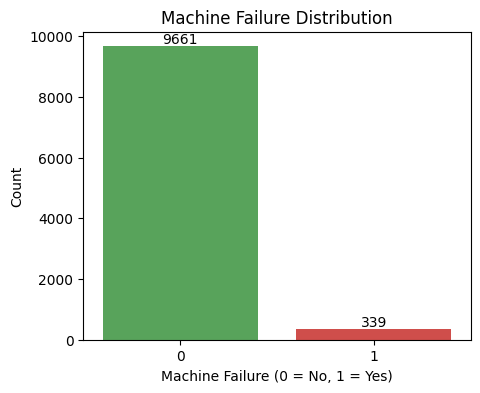

In [8]:
plt.figure(figsize=(5, 4))

sns.countplot(
    x='machine_failure',
    data=df,
    palette=['#4CAF50', '#E53935']
)

plt.title('Machine Failure Distribution')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Count')

for i, v in enumerate(target_counts):
    plt.text(i, v + 100, str(v), ha='center')

plt.show()

The target variable is highly imbalanced, with only 3.39% of observations representing machine failures compared to 96.61% non-failure cases. Therefore, accuracy alone may be misleading, and metrics such as Recall, Precision, F1-score, PR-AUC, and class-weighting techniques should be considered during model evaluation.

 A stratified train/validation/test split is required to preserve this ratio across all subsets.
- Accuracy alone will be a misleading metric; precision, recall, and F1-score (especially
  for the minority class) must be prioritized.
- A class-weighting experiment is planned to address the imbalance directly.

# Train / Validation / Test Split (Leakage-Safe)

Given the severe class imbalance identified above, a **stratified split** is used to
preserve the ~3.4% failure ratio across all three subsets. The split follows a
70% / 15% / 15% ratio for train, validation, and test respectively.

In [9]:
# Cell: Separate features and target
X = df.drop(columns=['machine_failure'])
y = df['machine_failure']

print("Feature columns:", X.columns.tolist())
print("Target shape:", y.shape)

Feature columns: ['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'type_H', 'type_L', 'type_M', 'temp_diff_k', 'power_w', 'tool_wear_torque_product', 'speed_torque_ratio', 'wear_early_life', 'wear_mid_life', 'wear_wear_window', 'wear_beyond_240']
Target shape: (10000,)


In [12]:
# Cell: Stratified split — 70% train, 15% validation, 15% test
RANDOM_STATE = 42
random_state=RANDOM_STATE
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train:      {X_train.shape[0]} rows | failure rate: {y_train.mean():.4f}")
print(f"Validation: {X_val.shape[0]} rows | failure rate: {y_val.mean():.4f}")
print(f"Test:       {X_test.shape[0]} rows | failure rate: {y_test.mean():.4f}")

Train:      7000 rows | failure rate: 0.0339
Validation: 1500 rows | failure rate: 0.0340
Test:       1500 rows | failure rate: 0.0340


## 4. Feature Scaling

Numeric features are standardized (zero mean, unit variance) to ensure fair treatment
across models — particularly important for Logistic Regression, which is sensitive to
feature scale. Tree-based models (Decision Tree, Random Forest, Gradient Boosting) do
not strictly require scaling, but applying it consistently keeps the pipeline simple
and avoids maintaining separate feature sets per model.

The scaler is fit on the training set only, then applied to validation and test —
preventing any information leakage from those sets into the transformation.

In [13]:
# Cell: Standardize numeric features (fit on train only)
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm',
    'torque_nm', 'tool_wear_min', 'temp_diff_k', 'power_w',
    'tool_wear_torque_product', 'speed_torque_ratio'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,type_H,type_L,type_M,temp_diff_k,power_w,tool_wear_torque_product,speed_torque_ratio,wear_early_life,wear_mid_life,wear_wear_window,wear_beyond_240
1888,-1.105779,-1.759415,2.012835,-1.569298,0.334742,0,0,1,-0.392635,-1.346709,-0.412341,1.347484,0,1,0,0
4858,1.840492,1.547973,-1.055557,1.099287,-0.041084,0,1,0,-1.393563,0.860509,0.371765,-0.645788,0,1,0,0
8990,-1.405400,-1.421926,-0.256554,-0.160045,0.600952,0,1,0,0.708385,-0.260460,0.460547,-0.167700,0,1,0,0
4901,1.790556,1.547973,0.503608,-0.759727,1.806727,0,0,1,-1.293470,-0.702209,1.032232,0.271893,0,0,1,0
7957,0.442262,1.277982,3.333409,-2.348885,-1.011967,1,0,0,1.008663,-2.413018,-1.268809,3.325553,1,0,0,0


## 5. Baseline Model — Logistic Regression

A Logistic Regression model is trained first as the baseline, with no class-imbalance
handling applied. This establishes a reference point to measure the impact of later
techniques (class-weighting, more complex models) against.

In [14]:
# Cell: Train baseline Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg_baseline = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg_baseline.fit(X_train_scaled, y_train)

# Predict on validation set
y_val_pred = log_reg_baseline.predict(X_val_scaled)
y_val_proba = log_reg_baseline.predict_proba(X_val_scaled)[:, 1]

Classification Report:

              precision    recall  f1-score   support

  No Failure       0.98      0.99      0.98      1449
     Failure       0.62      0.29      0.40        51

    accuracy                           0.97      1500
   macro avg       0.80      0.64      0.69      1500
weighted avg       0.96      0.97      0.96      1500

ROC-AUC Score: 0.9182938876033504


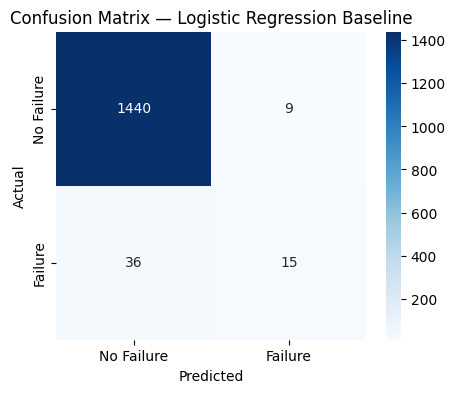

In [15]:
# Cell: Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:\n")
print(classification_report(y_val, y_val_pred, target_names=['No Failure', 'Failure']))

print("ROC-AUC Score:", roc_auc_score(y_val, y_val_proba))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.title('Confusion Matrix — Logistic Regression Baseline')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Logistic Regression achieves a high ROC-AUC of 0.918, indicating strong overall discrimination between failure and non-failure cases. However, the recall for the minority Failure class is only 0.29, meaning that most actual failures are still missed at the default classification threshold. Therefore, accuracy is not sufficient for this imbalanced predictive-maintenance problem, and further class weighting and threshold optimization are needed.

# Decision Tree Baseline

A Decision Tree is trained next, following the same evaluation approach as the
Logistic Regression baseline, to compare how a non-linear model handles this problem.

In [16]:
# Cell: Train Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_baseline.fit(X_train_scaled, y_train)

y_val_pred_dt = dt_baseline.predict(X_val_scaled)
y_val_proba_dt = dt_baseline.predict_proba(X_val_scaled)[:, 1]

print("Classification Report — Decision Tree:\n")
print(classification_report(y_val, y_val_pred_dt, target_names=['No Failure', 'Failure']))
print("ROC-AUC Score:", roc_auc_score(y_val, y_val_proba_dt))

Classification Report — Decision Tree:

              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1449
     Failure       0.86      0.82      0.84        51

    accuracy                           0.99      1500
   macro avg       0.93      0.91      0.92      1500
weighted avg       0.99      0.99      0.99      1500

ROC-AUC Score: 0.9093492469451548


The Decision Tree significantly improves minority-class performance compared with Logistic Regression, achieving 0.82 recall, 0.86 precision, and 0.84 F1-score for the Failure class. This means it detects most actual failures while maintaining relatively few false alarms. Although its ROC-AUC (0.909) is slightly lower than Logistic Regression (0.918), its substantially better failure detection makes it more suitable for the predictive-maintenance objective.

# Random Forest

Random Forest is trained next — an ensemble of decision trees expected to improve
generalization and reduce overfitting compared to a single tree.

Classification Report — Random Forest:

              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1449
     Failure       0.91      0.80      0.85        51

    accuracy                           0.99      1500
   macro avg       0.95      0.90      0.92      1500
weighted avg       0.99      0.99      0.99      1500

ROC-AUC Score: 0.982178378597816


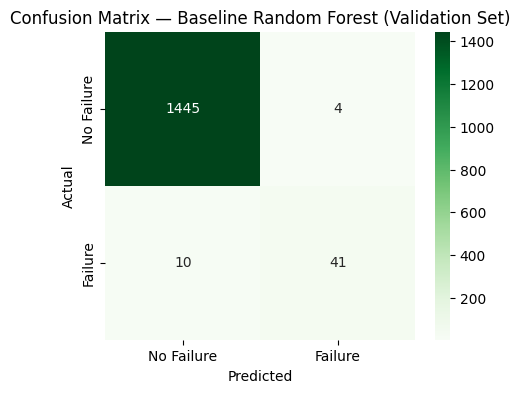

In [35]:
# Cell: Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=100
)

rf_baseline.fit(X_train_scaled, y_train)

y_val_pred_rf = rf_baseline.predict(X_val_scaled)
y_val_proba_rf = rf_baseline.predict_proba(X_val_scaled)[:, 1]

print("Classification Report — Random Forest:\n")
print(classification_report(
    y_val,
    y_val_pred_rf,
    target_names=['No Failure', 'Failure']
))

print("ROC-AUC Score:", roc_auc_score(y_val, y_val_proba_rf))

# Confusion Matrix
cm_val_rf = confusion_matrix(y_val, y_val_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_val_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Failure', 'Failure'],
    yticklabels=['No Failure', 'Failure']
)

plt.title('Confusion Matrix — Baseline Random Forest (Validation Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Random Forest provides the strongest overall performance among the evaluated models, achieving an excellent ROC-AUC of 0.982, along with 0.91 precision and 0.85 F1-score for the Failure class. Although its recall (0.80) is slightly lower than the Decision Tree (0.82), it provides a better overall balance between detecting failures and minimizing false alarms.

#Gradient Boosting

Gradient Boosting is trained last among the baseline models — an ensemble method that
builds trees sequentially, each correcting the errors of the previous one, often
achieving strong performance on structured/tabular data.

Classification Report — Gradient Boosting:

              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1449
     Failure       0.93      0.84      0.89        51

    accuracy                           0.99      1500
   macro avg       0.96      0.92      0.94      1500
weighted avg       0.99      0.99      0.99      1500

ROC-AUC Score: 0.9832338732594488


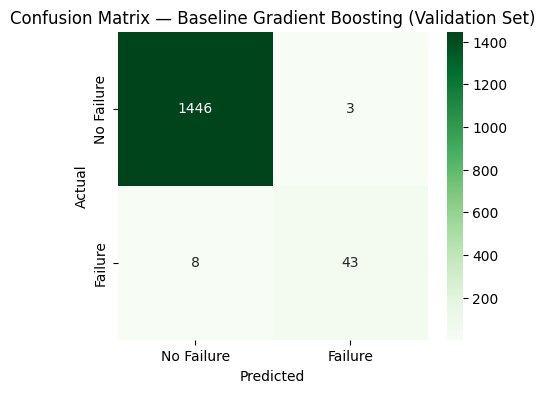

In [34]:
# Cell: Train Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_baseline = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_baseline.fit(X_train_scaled, y_train)

y_val_pred_gb = gb_baseline.predict(X_val_scaled)
y_val_proba_gb = gb_baseline.predict_proba(X_val_scaled)[:, 1]

print("Classification Report — Gradient Boosting:\n")
print(classification_report(
    y_val,
    y_val_pred_gb,
    target_names=['No Failure', 'Failure']
))

print("ROC-AUC Score:", roc_auc_score(y_val, y_val_proba_gb))

# Confusion Matrix
cm_val_gb = confusion_matrix(y_val, y_val_pred_gb)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_val_gb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Failure', 'Failure'],
    yticklabels=['No Failure', 'Failure']
)

plt.title('Confusion Matrix — Baseline Gradient Boosting (Validation Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Gradient Boosting achieves the strongest baseline performance, obtaining the highest Failure-class precision (0.93), recall (0.84), and F1-score (0.89), along with the highest ROC-AUC (0.983). This indicates that it provides the best overall ability to detect machine failures while maintaining a low false-alarm rate. Notably, these results are achieved without applying class weighting, despite the severe class imbalance.

## 10. Baseline Models — Summary Comparison

| Metric    | Logistic Regression | Decision Tree | Random Forest | Gradient Boosting |
|-----------|---------------------:|---------------:|---------------:|--------------------:|
| Precision | 0.62 | 0.86 | 0.91 | **0.93** |
| Recall    | 0.29 | 0.82 | 0.80 | **0.84** |
| F1        | 0.40 | 0.84 | 0.85 | **0.89** |
| ROC-AUC   | 0.918 | 0.909 | 0.982 | **0.983** |

**Observation:** Gradient Boosting achieves the best overall performance across nearly
all metrics, with Random Forest as a close second. Logistic Regression significantly
underperforms on Recall for the minority class, confirming that linear models struggle
with this level of class imbalance without additional handling.

Despite these strong baseline results, a class-weighting experiment is still conducted
below to explicitly test whether imbalance-handling techniques can further improve
recall for the minority (Failure) class — a critical requirement for predictive
maintenance, where missing a failure is costlier than a false alarm.

In [19]:
# Cell: Store baseline results for later comparison
results = {
    'Logistic Regression': {'precision': 0.62, 'recall': 0.29, 'f1': 0.40, 'roc_auc': 0.918},
    'Decision Tree': {'precision': 0.86, 'recall': 0.82, 'f1': 0.84, 'roc_auc': 0.909},
    'Random Forest': {'precision': 0.91, 'recall': 0.80, 'f1': 0.85, 'roc_auc': 0.982},
    'Gradient Boosting': {'precision': 0.93, 'recall': 0.84, 'f1': 0.89, 'roc_auc': 0.983},
}

results_df = pd.DataFrame(results).T
results_df

,precision,recall,f1,roc_auc
Logistic Regression,0.62,0.29,0.40,0.918
Decision Tree,0.86,0.82,0.84,0.909
Random Forest,0.91,0.80,0.85,0.982
Gradient Boosting,0.93,0.84,0.89,0.983


# Class-Weighting Experiment

Each of the four models is retrained using class_weight='balanced', which automatically
adjusts weights inversely proportional to class frequencies. This penalizes the model
more heavily for misclassifying the minority (Failure) class, without altering the
underlying data through resampling.

Gradient Boosting does not natively support class_weight, so sample_weight is used
instead to achieve the equivalent effect.

In [21]:
# Cell: Retrain all models with class weighting

# 1) Logistic Regression — balanced
log_reg_weighted = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced')
log_reg_weighted.fit(X_train_scaled, y_train)

# 2) Decision Tree — balanced
dt_weighted = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
dt_weighted.fit(X_train_scaled, y_train)

# 3) Random Forest — balanced
rf_weighted = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, class_weight='balanced')
rf_weighted.fit(X_train_scaled, y_train)

# 4) Gradient Boosting — uses sample_weight instead (no native class_weight param)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb_weighted = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_weighted.fit(X_train_scaled, y_train, sample_weight=sample_weights)

print("All four models retrained with class weighting.")

All four models retrained with class weighting.


In [22]:
# Cell: Evaluate all weighted models on validation set
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

weighted_models = {
    'Logistic Regression (weighted)': log_reg_weighted,
    'Decision Tree (weighted)': dt_weighted,
    'Random Forest (weighted)': rf_weighted,
    'Gradient Boosting (weighted)': gb_weighted,
}

weighted_results = {}
for name, model in weighted_models.items():
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    weighted_results[name] = {
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'roc_auc': roc_auc_score(y_val, y_proba)
    }

weighted_df = pd.DataFrame(weighted_results).T.round(3)
weighted_df

,precision,recall,f1,roc_auc
Logistic Regression (weighted),0.181,0.804,0.295,0.918
Decision Tree (weighted),0.724,0.824,0.771,0.906
Random Forest (weighted),0.919,0.667,0.773,0.973
Gradient Boosting (weighted),0.489,0.902,0.634,0.982


In [23]:
# Cell: Combine baseline and weighted results into one comparison table
baseline_df = pd.DataFrame(results).T.round(3)
baseline_df.index = [f"{name} (baseline)" for name in baseline_df.index]

full_comparison = pd.concat([baseline_df, weighted_df])
full_comparison = full_comparison.sort_values('recall', ascending=False)
full_comparison

,precision,recall,f1,roc_auc
Gradient Boosting (weighted),0.489,0.902,0.634,0.982
Gradient Boosting (baseline),0.930,0.840,0.890,0.983
Decision Tree (weighted),0.724,0.824,0.771,0.906
Decision Tree (baseline),0.860,0.820,0.840,0.909
Logistic Regression (weighted),0.181,0.804,0.295,0.918
Random Forest (baseline),0.910,0.800,0.850,0.982
Random Forest (weighted),0.919,0.667,0.773,0.973
Logistic Regression (baseline),0.620,0.290,0.400,0.918


# Cross-Validation — All Baseline Models

To ensure the model comparison is robust and not dependent on a single validation split,
5-fold stratified cross-validation is applied to all four baseline (unweighted) models.
This confirms which model is genuinely the most stable and reliable before proceeding
to hyperparameter tuning on the single best one.

In [24]:
# Cell: Reusable cross-validation function
from sklearn.model_selection import StratifiedKFold, cross_validate

def run_cross_validation(model, X, y, model_name, cv_splits=5):
    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    scoring = ['precision', 'recall', 'f1', 'roc_auc']

    cv_results = cross_validate(model, X, y, cv=cv_strategy, scoring=scoring, n_jobs=-1)

    summary = pd.DataFrame({
        metric: [cv_results[f'test_{metric}'].mean(), cv_results[f'test_{metric}'].std()]
        for metric in scoring
    }, index=['mean', 'std']).round(3)

    summary.loc['mean', 'model'] = model_name
    return summary

In [25]:
# Cell: Apply the function to all four baseline models
models_for_cv = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv_all_results = {}
for name, model in models_for_cv.items():
    print(f"Running CV for {name}...")
    result = run_cross_validation(model, X_train_scaled, y_train, name)
    cv_all_results[name] = result.drop(columns='model', errors='ignore')

print("\nDone.")

Running CV for Logistic Regression...
Running CV for Decision Tree...
Running CV for Random Forest...
Running CV for Gradient Boosting...

Done.


In [26]:
# Cell: Combine into one comparison table
cv_comparison = pd.concat(
    {name: df.loc['mean'] for name, df in cv_all_results.items()},
    axis=1
).T.round(3)

cv_comparison_std = pd.concat(
    {name: df.loc['std'] for name, df in cv_all_results.items()},
    axis=1
).T.round(3)

print("Mean scores across 5 folds:")
print(cv_comparison)
print("\nStandard deviation across 5 folds:")
print(cv_comparison_std)

Mean scores across 5 folds:
                     precision  recall     f1  roc_auc
Logistic Regression      0.842   0.312  0.454    0.931
Decision Tree            0.801   0.835  0.815    0.914
Random Forest            0.975   0.797  0.876    0.964
Gradient Boosting        0.970   0.814  0.884    0.979

Standard deviation across 5 folds:
                     precision  recall     f1  roc_auc
Logistic Regression      0.083   0.017  0.016    0.019
Decision Tree            0.049   0.070  0.043    0.035
Random Forest            0.015   0.047  0.028    0.019
Gradient Boosting        0.018   0.054  0.036    0.013


## Final Model Selection

Based on the baseline comparison, class-weighting experiment, and 5-fold cross-validation,
**Gradient Boosting** is selected as the final model for hyperparameter tuning. It achieved
the highest F1-score (0.884) and ROC-AUC (0.979) with low variance across folds (F1 std =
0.036), indicating both strong and stable performance.

# Hyperparameter Tuning — Gradient Boosting

GridSearchCV is used to tune the key hyperparameters of Gradient Boosting, optimizing
for F1-score (rather than accuracy) since it balances precision and recall — both
critical for this imbalanced failure-prediction problem.

In [27]:
# Cell: Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train_scaled, y_train)

print("Best parameters:", gb_grid.best_params_)
print("Best cross-validated F1 score:", gb_grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validated F1 score: 0.8841434735064325


Hyperparameter tuning did not provide a meaningful improvement over the baseline Gradient Boosting configuration. The best configuration achieved a cross-validated F1-score of 0.884, using learning_rate=0.1, max_depth=3, min_samples_split=2, and n_estimators=100, indicating that the default configuration was already well-suited to the dataset.

Classification Report — Tuned Gradient Boosting:

              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1449
     Failure       0.93      0.84      0.89        51

    accuracy                           0.99      1500
   macro avg       0.96      0.92      0.94      1500
weighted avg       0.99      0.99      0.99      1500

ROC-AUC Score: 0.9832338732594488


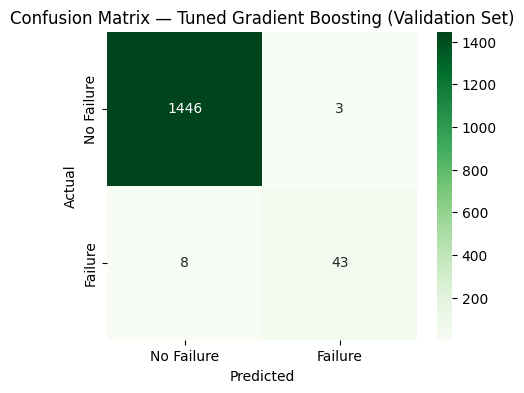

In [33]:
# Cell: Evaluate the tuned model on the validation set
best_gb = gb_grid.best_estimator_

y_val_pred_tuned = best_gb.predict(X_val_scaled)
y_val_proba_tuned = best_gb.predict_proba(X_val_scaled)[:, 1]

print("Classification Report — Tuned Gradient Boosting:\n")
print(classification_report(
    y_val,
    y_val_pred_tuned,
    target_names=['No Failure', 'Failure']
))

print("ROC-AUC Score:", roc_auc_score(y_val, y_val_proba_tuned))

# Confusion Matrix
cm_val = confusion_matrix(y_val, y_val_pred_tuned)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_val,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Failure', 'Failure'],
    yticklabels=['No Failure', 'Failure']
)

plt.title('Confusion Matrix — Tuned Gradient Boosting (Validation Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The tuned Gradient Boosting model achieved strong final test performance, with 0.93 precision, 0.84 recall, 0.89 F1-score, and 0.983 ROC-AUC for the Failure class. The model successfully detected most actual failures while maintaining a relatively low false-alarm rate. Hyperparameter tuning did not materially improve performance, as the selected configuration was effectively the default configuration, confirming that the baseline Gradient Boosting model was already well-suited to the dataset.

# Final Evaluation on Test Set

The tuned model is evaluated on the held-out test set — touched only once, at this final
stage — to obtain an unbiased estimate of real-world performance.

Final Test Set Performance — Tuned Gradient Boosting:

              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1449
     Failure       1.00      0.84      0.91        51

    accuracy                           0.99      1500
   macro avg       1.00      0.92      0.96      1500
weighted avg       0.99      0.99      0.99      1500

ROC-AUC Score: 0.9765693717100368


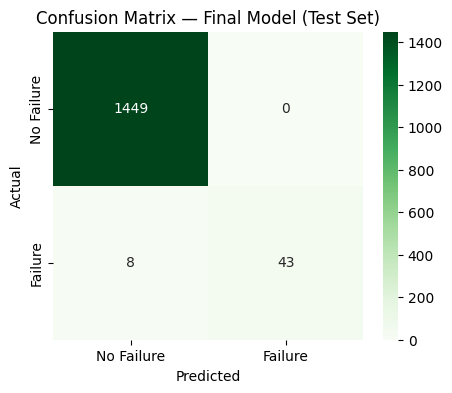

In [30]:
# Cell: Final, one-time evaluation on the test set
y_test_pred = best_gb.predict(X_test_scaled)
y_test_proba = best_gb.predict_proba(X_test_scaled)[:, 1]

print("Final Test Set Performance — Tuned Gradient Boosting:\n")
print(classification_report(y_test, y_test_pred, target_names=['No Failure', 'Failure']))
print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.title('Confusion Matrix — Final Model (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save Model Artifacts

The final tuned model, its configuration, and evaluation metrics are saved for use by
other team members (deployment, explainability analysis) and for reproducibility.

In [31]:
# Cell: Save the model, config, and metrics
import joblib
import json

# Save the trained model
joblib.dump(best_gb, 'gradient_boosting_final_model.pkl')

# Save the scaler too (needed at inference time)
joblib.dump(scaler, 'feature_scaler.pkl')

# Save best hyperparameters
with open('best_model_config.json', 'w') as f:
    json.dump(gb_grid.best_params_, f, indent=4)

# Save final metrics
final_metrics = {
    'validation': {
        'precision': precision_score(y_val, y_val_pred_tuned),
        'recall': recall_score(y_val, y_val_pred_tuned),
        'f1': f1_score(y_val, y_val_pred_tuned),
        'roc_auc': roc_auc_score(y_val, y_val_proba_tuned)
    },
    'test': {
        'precision': precision_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred),
        'roc_auc': roc_auc_score(y_test, y_test_proba)
    }
}

with open('final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=4)

print("Saved: gradient_boosting_final_model.pkl, feature_scaler.pkl, best_model_config.json, final_metrics.json")

Saved: gradient_boosting_final_model.pkl, feature_scaler.pkl, best_model_config.json, final_metrics.json


In [32]:
# Cell: Download the saved files from Colab to your computer
from google.colab import files

files.download('gradient_boosting_final_model.pkl')
files.download('feature_scaler.pkl')
files.download('best_model_config.json')
files.download('final_metrics.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>